In [1]:
import numpy as np
from scipy.special import softmax
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import ColumnDataSource
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from bokeh.transform import factor_cmap
output_notebook()

Loading BokehJS ...

In [2]:
import pandas as pd

col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(
    "census+income/adult.data",
    header=None,
    names=col_names,
    sep=r",\s*",
    engine="python",
    na_values="?"
)

# Keep fnlwgt out of model features for this experiment.
df = df.drop(columns=["fnlwgt"])

# Binary target: >50K -> 1, <=50K -> 0
df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
y = (df["income"] == ">50K").astype(int)
X = df.drop(columns=["income"])

print("Rows:", len(df))
print("Positive class rate:", y.mean())
print(X.head(2))

Rows: 32561
Positive class rate: 0.2408095574460244
   age         workclass  education  education_num      marital_status  \
0   39         State-gov  Bachelors             13       Never-married   
1   50  Self-emp-not-inc  Bachelors             13  Married-civ-spouse   

        occupation   relationship   race   sex  capital_gain  capital_loss  \
0     Adm-clerical  Not-in-family  White  Male          2174             0   
1  Exec-managerial        Husband  White  Male             0             0   

   hours_per_week native_country  
0              40  United-States  
1              13  United-States  


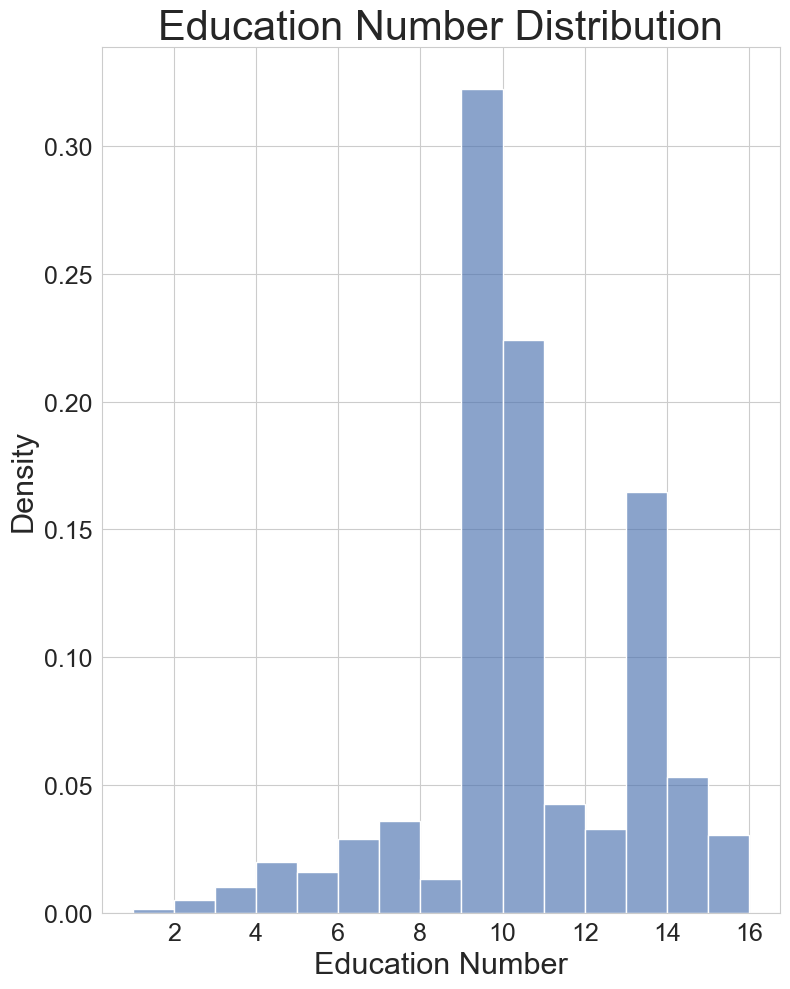

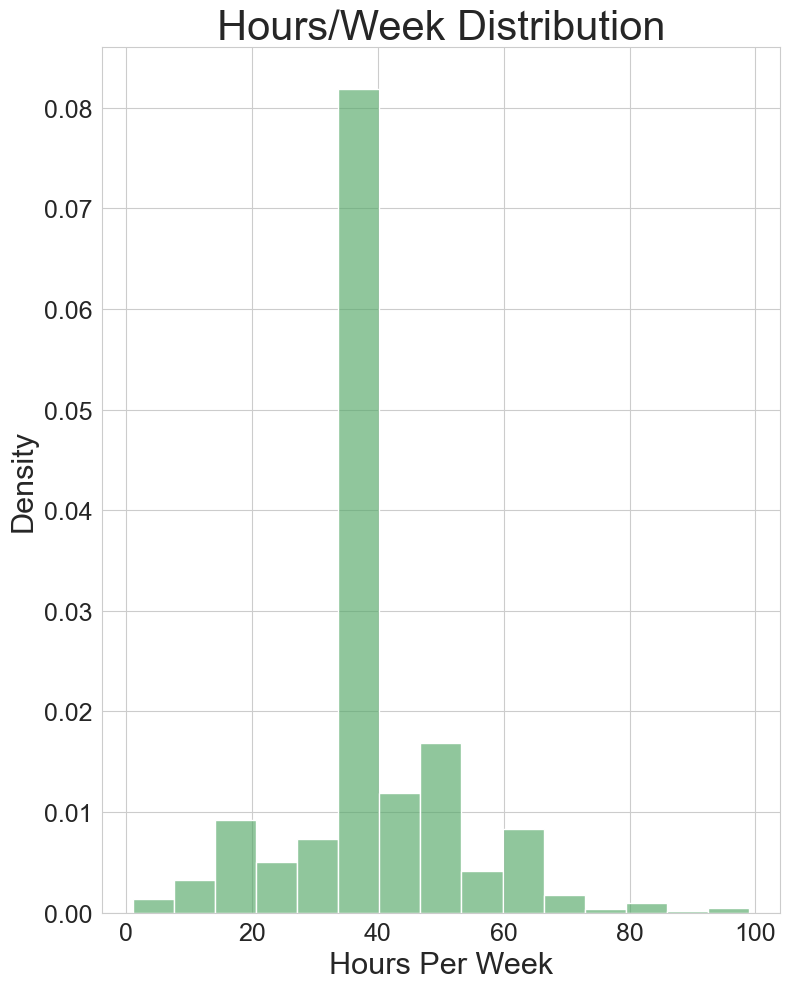

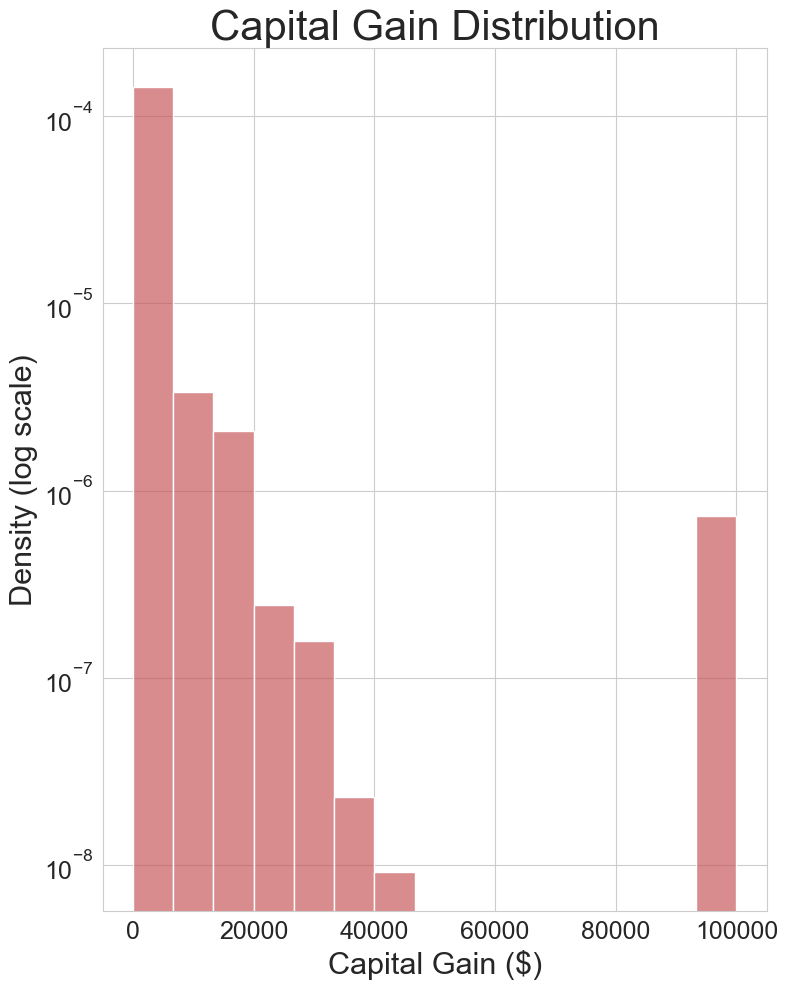

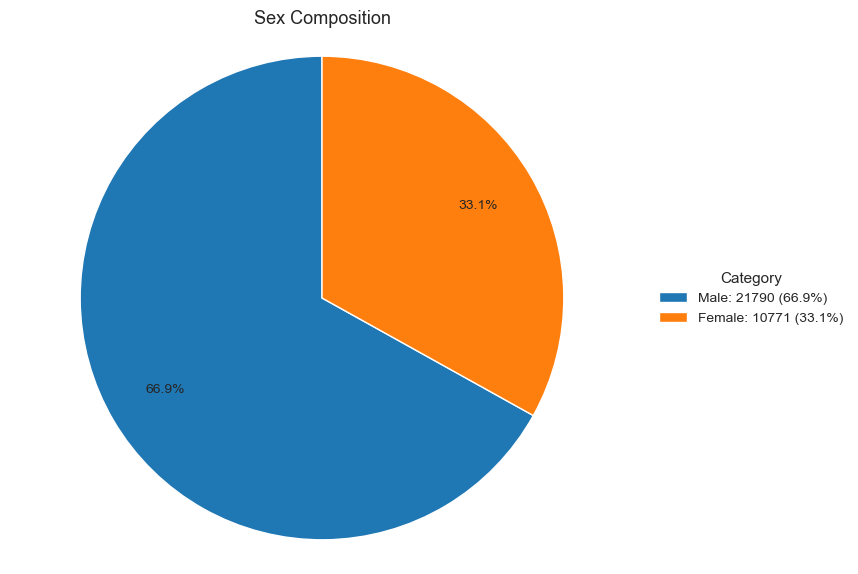

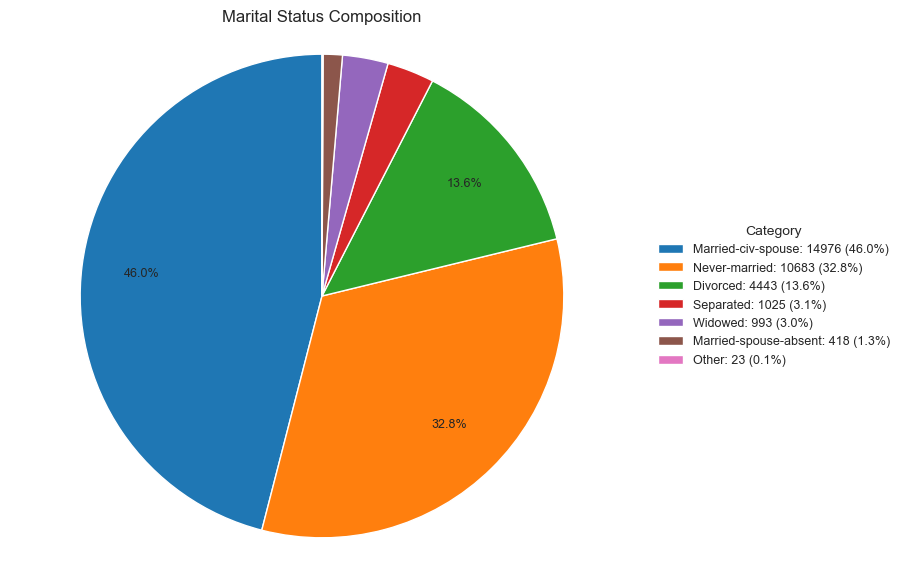

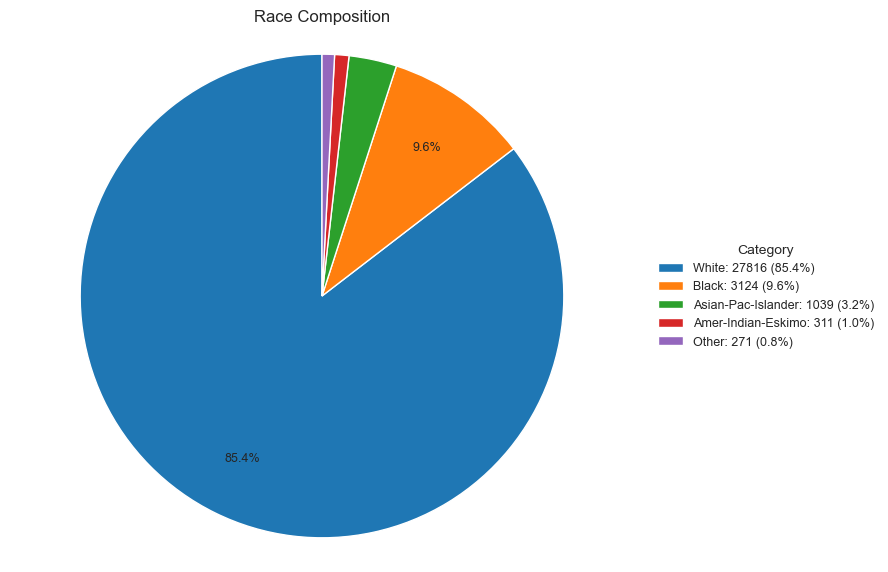

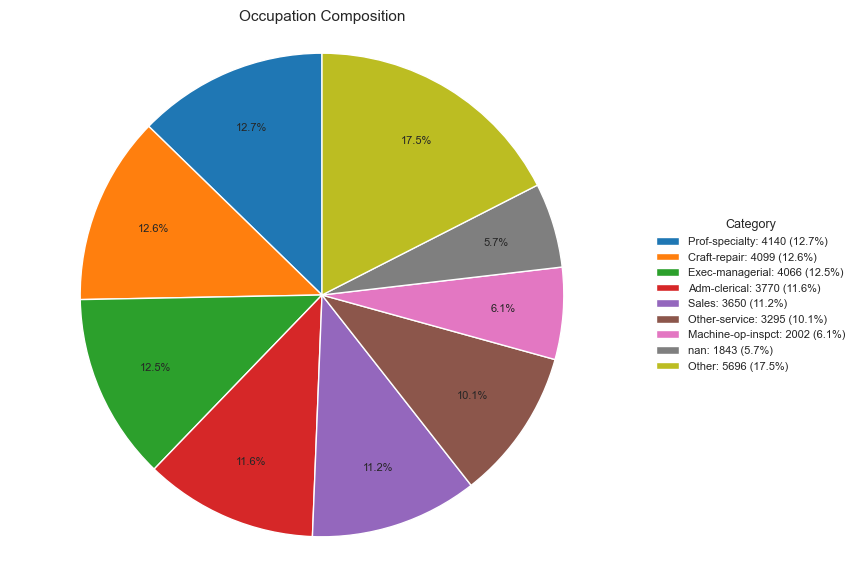

In [36]:
# Quick dataset introduction: separate plots for key numeric and categorical distributions.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# Larger histogram fonts for readability.
hist_title_fs = 30
hist_label_fs = 22
hist_tick_fs = 18

viz_df = df.copy()

# 1) Education number distribution (overall, no income split)
plt.figure(figsize=(8, 10))
sns.histplot(
    data=viz_df,
    x="education_num",
    bins=  15,
    stat="density",
    alpha=0.65,
    color="#4c72b0"
    )
plt.title("Education Number Distribution", fontsize=hist_title_fs)
plt.xlabel("Education Number", fontsize=hist_label_fs)
plt.ylabel("Density", fontsize=hist_label_fs)
plt.xticks(fontsize=hist_tick_fs)
plt.yticks(fontsize=hist_tick_fs)
plt.tight_layout()
plt.show()

# 2) Weekly hours worked distribution (overall, no income split)
plt.figure(figsize=(8, 10))
sns.histplot(
    data=viz_df,
    x="hours_per_week",
    bins=  15,
    stat="density",
    alpha=0.65,
    color="#55a868"
    )
plt.title("Hours/Week Distribution", fontsize=hist_title_fs)
plt.xlabel("Hours Per Week", fontsize=hist_label_fs)
plt.ylabel("Density", fontsize=hist_label_fs)
plt.xticks(fontsize=hist_tick_fs)
plt.yticks(fontsize=hist_tick_fs)
plt.tight_layout()
plt.show()

# 3) Capital gain distribution (overall, no income split)
plt.figure(figsize=(8, 10))
sns.histplot(
    data=viz_df,
    x="capital_gain",
    bins=  15,
    stat="density",
    alpha=0.65,
    color="#c44e52"
    )
plt.yscale("log")
plt.title("Capital Gain Distribution", fontsize=hist_title_fs)
plt.xlabel("Capital Gain ($)", fontsize=hist_label_fs)
plt.ylabel("Density (log scale)", fontsize=hist_label_fs)
plt.xticks(fontsize=hist_tick_fs)
plt.yticks(fontsize=hist_tick_fs)
plt.tight_layout()
plt.show()

def plot_pie_with_other(series, title, top_k=None, fontsize=10, min_pct_label=4.0):
    counts = series.value_counts(dropna=False)
    if top_k is not None and len(counts) > top_k:
        top = counts.head(top_k)
        other = counts.iloc[top_k:].sum()
        values = list(top.values) + [other]
        labels = [str(x) for x in list(top.index) + ["Other"]]
    else:
        values = counts.values
        labels = [str(x) for x in counts.index]

    total = sum(values)

    def _autopct(pct):
        return f"{pct:.1f}%" if pct >= min_pct_label else ""

    # Keep a fixed pie drawing area so pie sizes stay visually consistent.
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_position([0.06, 0.12, 0.52, 0.76])

    wedges, _, autotexts = ax.pie(
        values,
        labels=None,
        autopct=_autopct,
        startangle=90,
        pctdistance=0.75,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        textprops={"fontsize": fontsize}
    )

    for text in autotexts:
        text.set_fontsize(max(fontsize - 1, 8))

    legend_labels = [f"{label}: {value} ({100 * value / total:.1f}%)" for label, value in zip(labels, values)]
    ax.legend(
        wedges,
        legend_labels,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=max(fontsize - 1, 8),
        title_fontsize=fontsize
    )

    ax.set_title(title, fontsize=fontsize + 2)
    ax.axis("equal")
    plt.show()

# 3) Sex composition
plot_pie_with_other(viz_df["sex"], "Sex Composition", fontsize=11)

# 4) Marital status composition
plot_pie_with_other(viz_df["marital_status"], "Marital Status Composition", top_k=6, fontsize=10)

# 5) Race composition
plot_pie_with_other(viz_df["race"], "Race Composition", top_k=6, fontsize=10)

# 6) Occupation composition
plot_pie_with_other(viz_df["occupation"], "Occupation Composition", top_k=8, fontsize=9)

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "age", "education_num", "capital_gain", "capital_loss", "hours_per_week"
]

categorical_features = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=11, stratify=y
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8491585800270237

Confusion matrix:
 [[5750  431]
 [ 797 1163]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      6181
           1       0.73      0.59      0.65      1960

    accuracy                           0.85      8141
   macro avg       0.80      0.76      0.78      8141
weighted avg       0.84      0.85      0.84      8141



Saved Logistic Regression confusion matrix to: exports\logistic_regression_confusion_matrix.csv


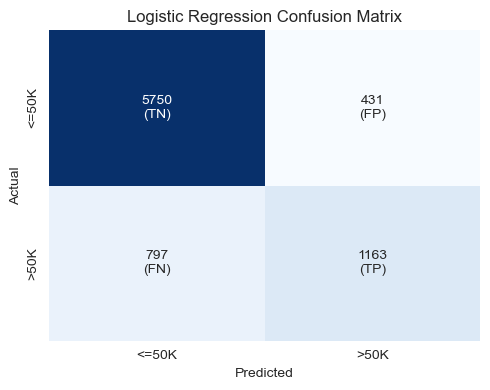

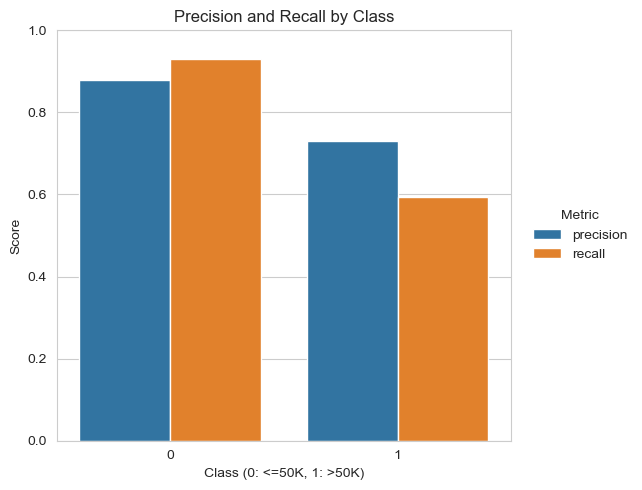

,class,precision,recall
0,0,0.878265,0.930270
1,1,0.729611,0.593367


In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

# Export matrix for cross-model comparison plots.
os.makedirs("exports", exist_ok=True)
lr_cm_path = os.path.join("exports", "logistic_regression_confusion_matrix.csv")
np.savetxt(lr_cm_path, cm, fmt="%d", delimiter=",")
print(f"Saved Logistic Regression confusion matrix to: {lr_cm_path}")

# Match Naive Bayes confusion matrix formatting.
cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
annot_labels = np.array([
    [f"{cm[i, j]}\n({cell_labels[i, j]})" for j in range(2)]
    for i in range(2)
], dtype=object)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
    )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

# Match Naive Bayes precision/recall chart formatting.
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

# Keep only class rows (exclude accuracy/macro avg/weighted avg).
class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=metrics_long,
    x="class",
    y="score",
    hue="metric",
    palette=["#1f77b4", "#ff7f0e"],
    ax=ax
    )
ax.set_ylim(0, 1)
ax.set_title("Precision and Recall by Class")
ax.set_xlabel("Class (0: <=50K, 1: >50K)")
ax.set_ylabel("Score")
ax.legend(title="Metric", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

display(metrics_df)

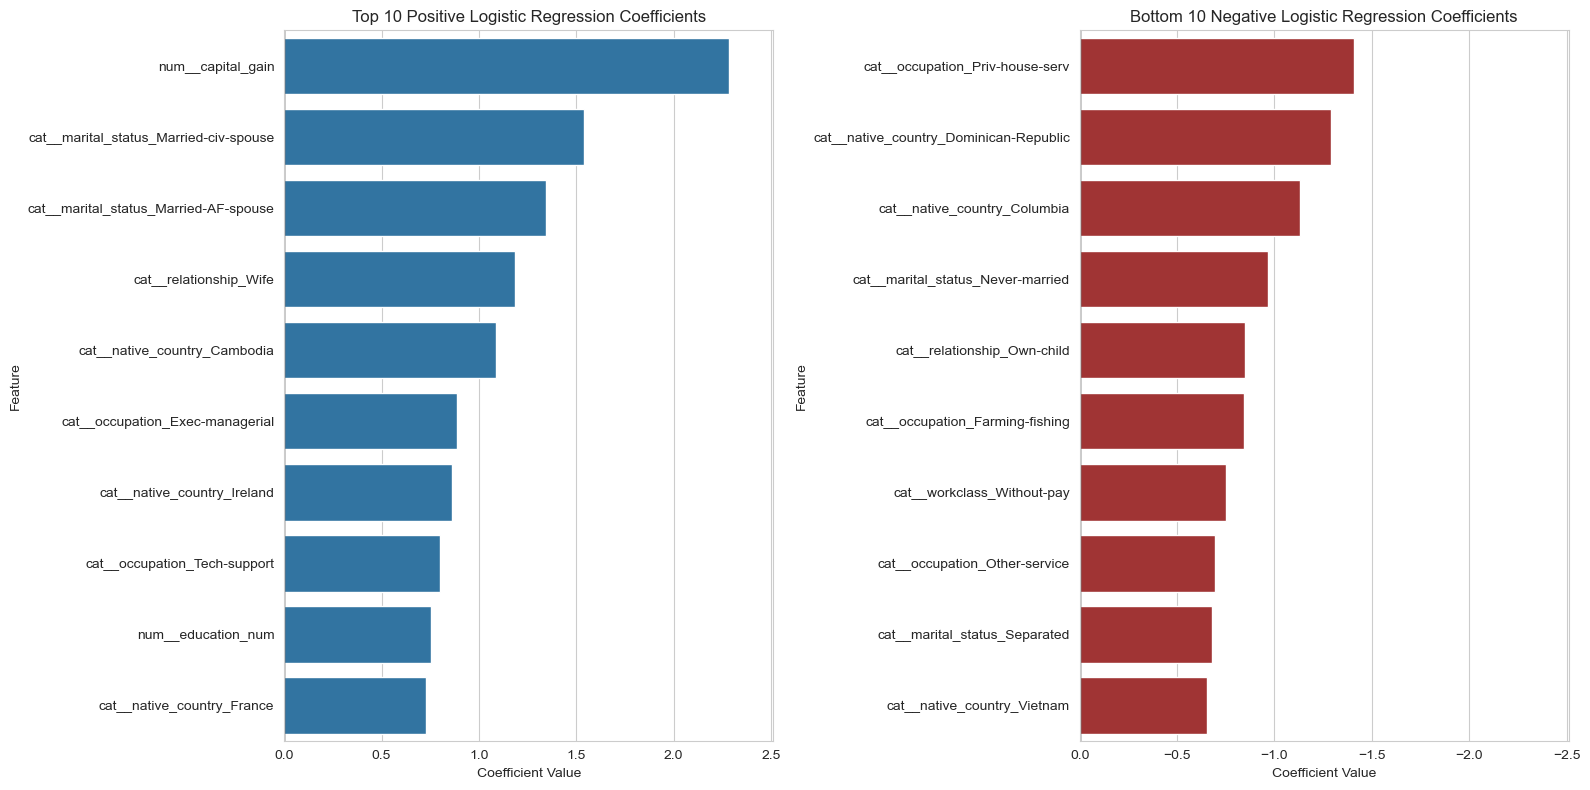

Top 10 positive coefficients (largest absolute value first):


,feature,coefficient
2,num__capital_gain,2.283334
31,cat__marital_status_Married-civ-spouse,1.540825
30,cat__marital_status_Married-AF-spouse,1.344942
55,cat__relationship_Wife,1.185820
63,cat__native_country_Cambodia,1.087702
39,cat__occupation_Exec-managerial,0.884816
82,cat__native_country_Ireland,0.861728
48,cat__occupation_Tech-support,0.801535
1,num__education_num,0.752320
72,cat__native_country_France,0.727213


Bottom 10 negative coefficients (largest absolute value first):


,feature,coefficient
44,cat__occupation_Priv-house-serv,-1.407632
68,cat__native_country_Dominican-Republic,-1.289006
66,cat__native_country_Columbia,-1.128962
33,cat__marital_status_Never-married,-0.969216
53,cat__relationship_Own-child,-0.851076
40,cat__occupation_Farming-fishing,-0.846214
12,cat__workclass_Without-pay,-0.752684
43,cat__occupation_Other-service,-0.697480
34,cat__marital_status_Separated,-0.677721
101,cat__native_country_Vietnam,-0.652746


In [ ]:
# Plot top and bottom logistic regression coefficients in separate subplots.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pull feature names after preprocessing (numeric + one-hot categorical).
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
coefficients = clf.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

top_n = 10

# Positive and negative groups, each ordered so largest absolute value appears at the top.
top_features = coef_df[coef_df["coefficient"] > 0].nlargest(top_n, "coefficient")
top_features = top_features.sort_values("abs_coefficient", ascending=False)

bottom_features = coef_df[coef_df["coefficient"] < 0].nsmallest(top_n, "coefficient")
bottom_features = bottom_features.sort_values("abs_coefficient", ascending=False)

# Use the same absolute x-limit on both subplots for direct bar-length comparison.
pos_max = top_features["coefficient"].max() if len(top_features) else 0
neg_abs_max = np.abs(bottom_features["coefficient"].min()) if len(bottom_features) else 0
shared_abs_limit = max(pos_max, neg_abs_max) * 1.1 if max(pos_max, neg_abs_max) > 0 else 1

# Toggle these to quickly resize all plot text.
title_fs = 18
label_fs = 14
tick_fs = 12

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature",
    order=top_features["feature"],
    color="#1f77b4",
    ax=axes[0]
    )
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlim(0, shared_abs_limit)
axes[0].set_title("Top 10 Positive Logistic Regression Coefficients", fontsize=title_fs)
axes[0].set_xlabel("Coefficient Value", fontsize=label_fs)
axes[0].set_ylabel("Feature", fontsize=label_fs)
axes[0].tick_params(axis="both", labelsize=tick_fs)

sns.barplot(
    data=bottom_features,
    x="coefficient",
    y="feature",
    order=bottom_features["feature"],
    color="#b22222",
    ax=axes[1]
    )
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(0, -shared_abs_limit)
axes[1].set_title("Bottom 10 Negative Logistic Regression Coefficients", fontsize=title_fs)
axes[1].set_xlabel("Coefficient Value", fontsize=label_fs)
axes[1].set_ylabel("Feature", fontsize=label_fs)
axes[1].tick_params(axis="both", labelsize=tick_fs)

plt.tight_layout()
plt.show()

print("Top 10 positive coefficients (largest absolute value first):")
display(top_features[["feature", "coefficient"]])

print("Bottom 10 negative coefficients (largest absolute value first):")
display(bottom_features[["feature", "coefficient"]])